# Image Classification on CIFAR-10 Using CNNs


In [6]:
!pip install tensorflow

In [7]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

#### Load and normalize data

In [10]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

In [11]:
X_test.shape

(10000, 32, 32, 3)

In [12]:
X_train.shape

(50000, 32, 32, 3)

In [13]:
y_train.shape

(50000, 1)

In [14]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [22]:
y_train = y_train.reshape(-1)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [24]:
y_test = y_test.reshape(-1)

#### Define class names for visualization

In [27]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [29]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15, 2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

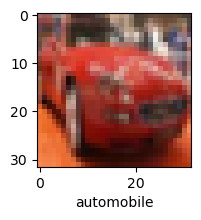

In [31]:
plot_sample(X_train, y_train, 5)

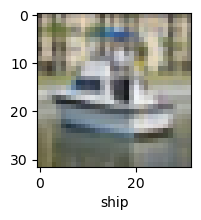

In [33]:
plot_sample(X_train, y_train, 501)

In [35]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## 2. The Baseline CNN (Tutorial Code)
This is the standard, lightweight CNN. While it runs quickly, it lacks regularization (like Dropout) and is highly prone to overfitting on small datasets like CIFAR-10.

In [15]:
ann = models.Sequential([
    layers.Flatten(input_shape = (32, 32, 3)),
    layers.Dense(3000, activation = 'relu'), 
    layers.Dense(1000, activation = 'relu'), 
    layers.Dense(10, activation = 'softmax')
])

ann.compile(optimizer = 'SGD',
            loss = 'sparse_categorical_crossentropy',
            metrics = ['accuracy'])

ann.fit(X_train, y_train, epochs = 5)

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 59ms/step - accuracy: 0.3565 - loss: 1.8084
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.4282 - loss: 1.6184
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.4551 - loss: 1.5398
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 59ms/step - accuracy: 0.4790 - loss: 1.4800
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 158s 101ms/step - accuracy: 0.4970 - loss: 1.4312


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print('classification report: \n', classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step
classification report: 
               precision    recall  f1-score   support

           0       0.55      0.57      0.56      1000
           1       0.50      0.74      0.60      1000
           2       0.34      0.43      0.38      1000
           3       0.27      0.56      0.37      1000
           4       0.60      0.16      0.25      1000
           5       0.43      0.32      0.37      1000
           6       0.61      0.36      0.45      1000
           7       0.63      0.50      0.56      1000
           8       0.57      0.65      0.61      1000
           9       0.62      0.38      0.47      1000

    accuracy                           0.47     10000
   macro avg       0.51      0.47      0.46     10000
weighted avg       0.51      0.47      0.46     10000



In [17]:
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

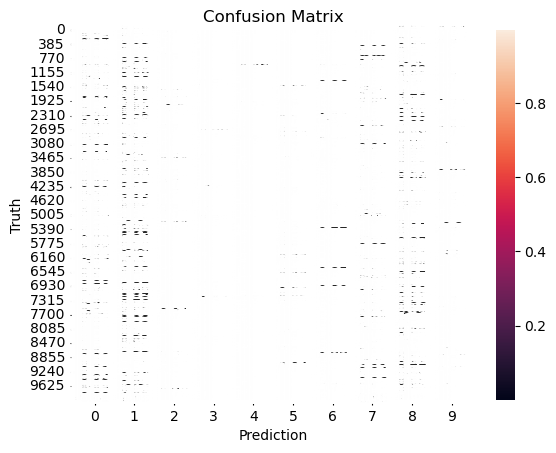

In [18]:
plt.figure(figure = (14, 7))
sns.heatmap(y_pred, annot = True)
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show

In [19]:
cnn = models.Sequential([
    layers.Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu', input_shape = (32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(10, activation = 'softmax')
])

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
cnn.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [21]:
cnn.fit(X_train, y_train, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 64ms/step - accuracy: 0.4809 - loss: 1.4569
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 66ms/step - accuracy: 0.6208 - loss: 1.0881
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.6662 - loss: 0.9608
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 63ms/step - accuracy: 0.6947 - loss: 0.8743
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 128s 54ms/step - accuracy: 0.7202 - loss: 0.8110
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 190s 76ms/step - accuracy: 0.7385 - loss: 0.7527
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 112s 72ms/step - accuracy: 0.7555 - loss: 0.7022
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 42ms/step - accuracy: 0.7702 - loss: 0.6570
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7863 - loss: 0.6120
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.7998 - loss: 0.5745


In [22]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6912 - loss: 0.9640


[0.964019238948822, 0.6912000179290771]

In [23]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


array([[2.4806088e-04, 3.5805679e-03, 1.4258532e-02, 9.1662449e-01,
        5.9760502e-03, 7.1293507e-03, 3.8825430e-02, 1.5133651e-06,
        1.3346884e-02, 9.1650691e-06],
       [1.1118265e-02, 3.0331868e-01, 2.4787839e-06, 2.0506975e-07,
        6.2971562e-06, 1.0241281e-08, 2.4308571e-09, 8.0381019e-10,
        6.8510616e-01, 4.4785871e-04],
       [8.3151452e-02, 2.1584560e-01, 5.8010132e-03, 5.2261800e-03,
        8.5373968e-03, 5.5523787e-04, 4.0826242e-04, 6.6554399e-05,
        6.6591108e-01, 1.4497210e-02],
       [8.4647751e-01, 3.9215412e-02, 7.1533389e-02, 2.0862311e-04,
        1.8594872e-03, 4.3873379e-06, 1.5202195e-03, 1.4308540e-06,
        3.9163765e-02, 1.5657613e-05],
       [1.7218004e-05, 2.9347852e-04, 1.5942583e-02, 2.5371481e-02,
        8.7261118e-02, 6.0986192e-04, 8.7045628e-01, 2.5131371e-07,
        4.1522846e-05, 6.1842161e-06]], dtype=float32)

In [24]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 8, 8, 0, 6]

In [25]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

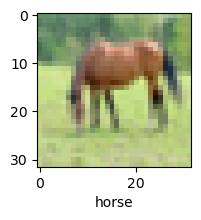

In [26]:
plot_sample(X_test, y_test, 60)

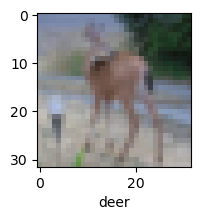

In [27]:
plot_sample(X_test, y_test, 100)

In [28]:
classes[y_classes[60]]

'horse'

## 3. The Enhanced CNN (`new_CNN`)

In [119]:
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Data Augmentation ---
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# --- Enhanced CNN Model ---
new_cnn = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

new_cnn.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Train with augmented data
new_cnn.fit(datagen.flow(X_train, y_train, batch_size=64),
            epochs=20,
            validation_data=(X_test, y_test))

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 323s 396ms/step - accuracy: 0.4102 - loss: 1.7271 - val_accuracy: 0.4894 - val_loss: 1.4726
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 326s 416ms/step - accuracy: 0.5613 - loss: 1.2248 - val_accuracy: 0.5765 - val_loss: 1.2633
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 310s 396ms/step - accuracy: 0.6245 - loss: 1.0589 - val_accuracy: 0.6401 - val_loss: 1.0949
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 327s 418ms/step - accuracy: 0.6581 - loss: 0.9665 - val_accuracy: 0.7042 - val_loss: 0.8538
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 309s 395ms/step - accuracy: 0.6854 - loss: 0.8948 - val_accuracy: 0.6681 - val_loss: 0.9532
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 307s 392ms/step - accuracy: 0.7027 - loss: 0.8534 - val_accuracy: 0.7337 - val_loss: 0.7633
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 388s 477ms/step - accuracy: 0.7175 - loss: 0.8139 - val_accuracy: 0.7527 - val_loss: 0.7079
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 576s 737ms/step - accuracy: 0.7285 -

=== Original CNN ===
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6912 - loss: 0.9640
=== Enhanced CNN ===
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.8089 - loss: 0.5684
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step
              precision    recall  f1-score   support

    airplane       0.85      0.80      0.83      1000
  automobile       0.94      0.93      0.93      1000
        bird       0.89      0.63      0.74      1000
         cat       0.73      0.63      0.68      1000
        deer       0.76      0.81      0.78      1000
         dog       0.88      0.62      0.73      1000
        frog       0.58      0.97      0.73      1000
       horse       0.92      0.83      0.87      1000
        ship       0.86      0.94      0.90      1000
       truck       0.86      0.94      0.90      1000

    accuracy                           0.81     10000
   macro avg       0.83      0.81      0.81     10000
weighted avg       0.83      0.81      0.81     10000



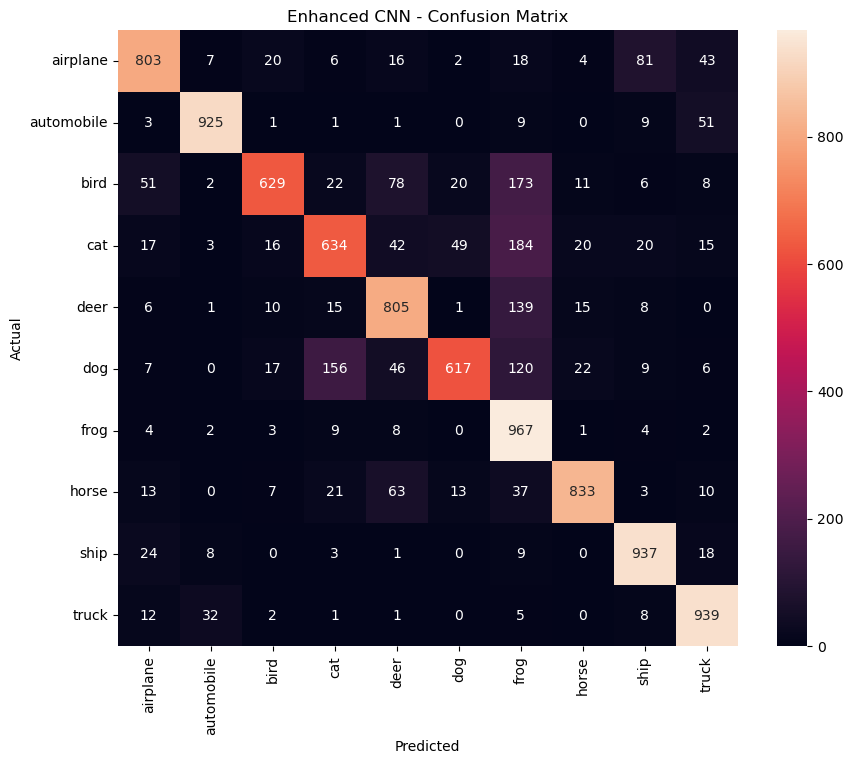

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate both
print("=== Original CNN ===")
cnn.evaluate(X_test, y_test)

print("=== Enhanced CNN ===")
new_cnn.evaluate(X_test, y_test)

# Classification report for new_cnn
y_pred_new = new_cnn.predict(X_test)
y_pred_new_classes = [np.argmax(e) for e in y_pred_new]
print(classification_report(y_test, y_pred_new_classes, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_new_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Enhanced CNN - Confusion Matrix')
plt.show()

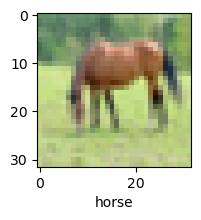

In [39]:
plot_sample(X_test, y_test, 60)